In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [8]:
# Download 2 years of daily data for both tickers
tickers = ["AAPL", "SPY", "META"]
raw = yf.download(tickers, period="2y", auto_adjust=True)

# Pull just the closing prices — a DataFrame with 2 columns
prices = raw["Close"]
prices.columns.name = None          # tidy up column name metadata
print(prices.tail())                # confirm download worked
print(f"\nShape: {prices.shape}")   # (trading_days, 2)


[*********************100%***********************]  3 of 3 completed

                  AAPL        META         SPY
Date                                          
2026-03-10  260.829987  654.070007  677.179993
2026-03-11  260.809998  654.859985  676.330017
2026-03-12  255.759995  638.179993  666.059998
2026-03-13  250.119995  613.710022  662.289978
2026-03-16  252.550003  626.914978  669.455017

Shape: (500, 3)


In [9]:
# Daily returns: (today - yesterday) / yesterday
# pct_change() does exactly this, row by row
returns = prices.pct_change().dropna()
print("Mean daily return:")
print(returns.mean().round(4))      # e.g. AAPL: 0.0008 = 0.08%/day

Mean daily return:
AAPL    0.0009
META    0.0007
SPY     0.0006
dtype: float64


In [12]:
# Rolling mean: average of the last N closing prices
# 20-day ≈ 1 month, 50-day ≈ quarter
ma20  = prices.rolling(window=20).mean()
ma50  = prices.rolling(window=50).mean()

# First 49 rows of ma50 will be NaN — not enough history yet
print(ma20["AAPL"].tail())
print(ma20["SPY"].tail())
print(ma20["META"].tail())

Date
2026-03-10    264.960500
2026-03-11    264.317000
2026-03-12    263.330000
2026-03-13    262.749499
2026-03-16    262.587999
Name: AAPL, dtype: float64
Date
2026-03-10    684.465500
2026-03-11    683.676001
2026-03-12    682.381000
2026-03-13    681.431998
2026-03-16    680.817249
Name: SPY, dtype: float64
Date
2026-03-10    651.531497
2026-03-11    650.738498
2026-03-12    649.212997
2026-03-13    647.407999
2026-03-16    646.765247
Name: META, dtype: float64


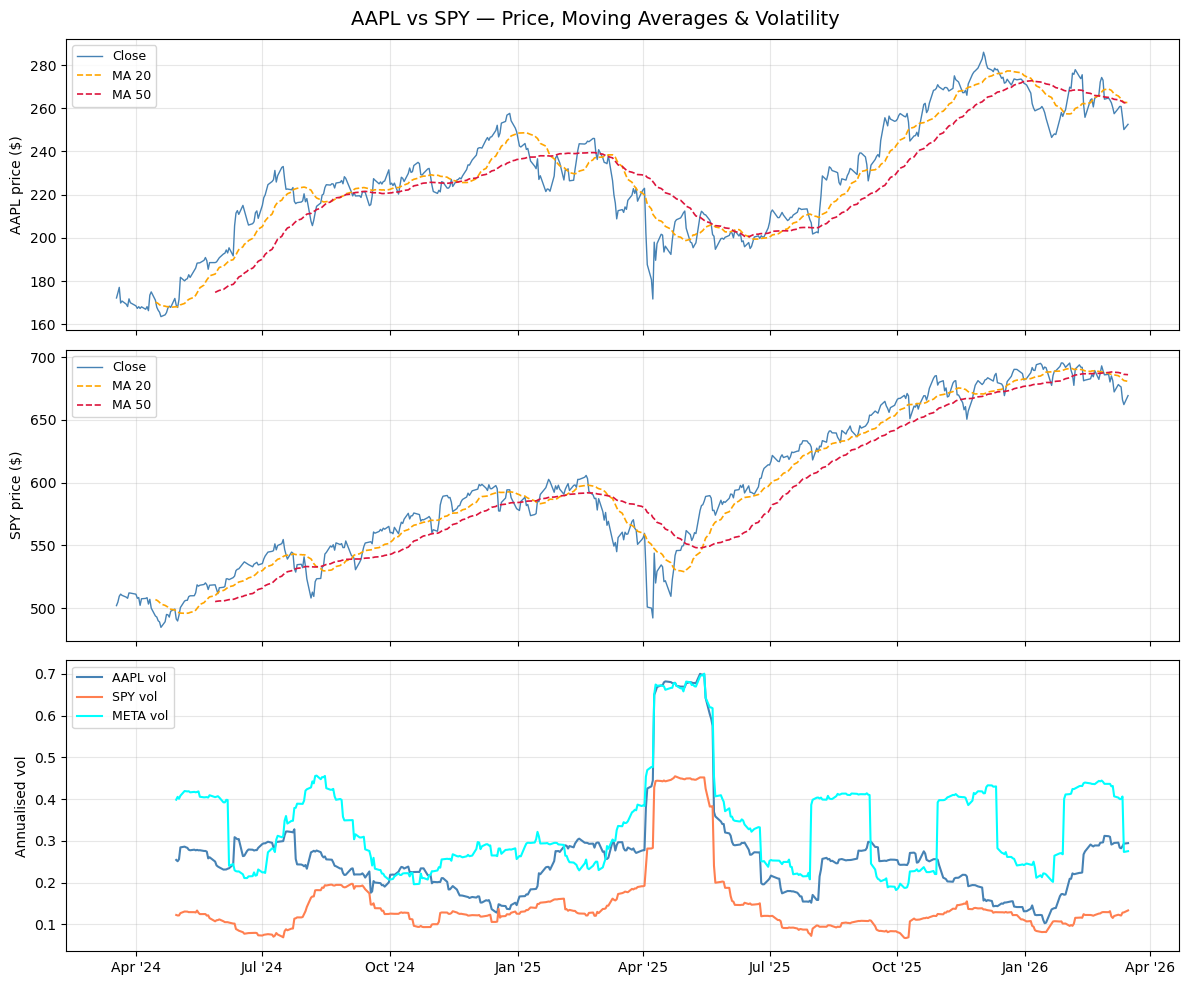

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("AAPL vs SPY — Price, Moving Averages & Volatility", fontsize=14)
returns = prices.pct_change().dropna()
vol_rolling = returns.rolling(30).std() * (252 ** 0.5)
for i, ticker in enumerate(["AAPL", "SPY"]):
    ax = axes[i]
    ax.plot(prices[ticker],  label="Close",   linewidth=1,   color="steelblue")
    ax.plot(ma20[ticker],    label="MA 20",   linewidth=1.2, color="orange",    linestyle="--")
    ax.plot(ma50[ticker],    label="MA 50",   linewidth=1.2, color="crimson",   linestyle="--")
    ax.set_ylabel(f"{ticker} price ($)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)

# Bottom panel: rolling volatility for both
axes[2].plot(vol_rolling["AAPL"], label="AAPL vol", color="steelblue")
axes[2].plot(vol_rolling["SPY"],  label="SPY vol",  color="coral")
axes[2].plot(vol_rolling["META"],  label="META vol",  color="cyan")
axes[2].set_ylabel("Annualised vol")
axes[2].legend(loc="upper left", fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

plt.tight_layout()
plt.savefig("stock_analysis.png", dpi=150)   # save for GitHub
plt.show()
